## 유방암 진단셋을 활용한 이진분류 (모델 클래스화)

### 1. 데이터셋 불러오기

In [64]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# 한글 폰트 설정 (Mac은 AppleGothic)
plt.rcParams["font.family"] = "Malgun Gothic"

# 마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False


In [65]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

In [71]:
# 데이터 프레임으로 변환
df = pd.DataFrame(data = cancer.data, columns = cancer.feature_names)

# 타겟 컬럼 추가
df['target'] = cancer.target

In [67]:
import torch

In [73]:
data = torch.from_numpy(df.drop('target', axis=1).values).float()  # DataFrame 의 값들만 Numpy배열에서 FloatTorch 형태로 변환

# target = torch.from_(df['target'])

data.shape


torch.Size([569, 30])

In [77]:
X = data

y = torch.tensor(df['target'].values).float().reshape(-1,1)

print(X.shape, y.shape)


torch.Size([569, 30]) torch.Size([569, 1])


In [90]:
# 학습 하이퍼파라미터 설정

n_epochs = 200000
learning_rate = 1e-3    # 학습률 
print_interval = 10000   # loss출력횟수


In [79]:
import torch.nn as nn

In [91]:
# 단층 퍼셉트론 모델 클래스 (nn.Module을 상속받음) : 입력 -> 선형변환(단층) -> 활성화함수
class MyModel(nn.Module):
    
    def __init__(self, input_dim, output_dim):
        self.input_dim = input_dim          # 입력 특성 차원수
        self.output_dim = output_dim        # 출력 차원 수 (노드)
        
        super().__init__()          # 상속받은 nn.Module을 초기화
        
        self.linear = nn.Linear(input_dim, output_dim)  # 입력 -> 출력 선형 변환
        # self.act = nn.Sigmoid()         # 출력값을 0~1 반환하는 이진분류 출력층 활성화 함수
    
    def forward(self, X):
        y = self.linear(X)    # 선형변환 후 로짓출력
        
        return y
        

In [92]:
X.size(-1)

30

In [95]:
import torch.optim as optim

model  = MyModel(input_dim= X.size(-1) ,    # 입력차원(노드)
                 output_dim= y.size(-1)     # 출력차원(노드)
                 )                          # 차원 = 컬럼갯수

criterion = nn.BCEWithLogitsLoss()    # 이진분류용 손실함수

optimizer = optim.Adam(
    model.parameters(),     # 업데이트 할 값(모델의 가중치, 편향)
    lr = learning_rate      # 학습률
    )

In [96]:
for i in range(n_epochs):
    y_hat = model(X)
    loss = criterion(y_hat, y)
    
    optimizer.zero_grad()
    
    loss.backward()
    optimizer.step()
    
    if (i+1) % print_interval ==0 :
        print(f'Epoch {i+1} loss : {loss.item():.4f}')

Epoch 10000 loss : 0.0740
Epoch 20000 loss : 0.0569
Epoch 30000 loss : 0.0495
Epoch 40000 loss : 0.0454
Epoch 50000 loss : 0.0433
Epoch 60000 loss : 0.0419
Epoch 70000 loss : 0.0410
Epoch 80000 loss : 0.0403
Epoch 90000 loss : 0.0398
Epoch 100000 loss : 0.0393
Epoch 110000 loss : 0.0389
Epoch 120000 loss : 0.0385
Epoch 130000 loss : 0.0382
Epoch 140000 loss : 0.0383
Epoch 150000 loss : 0.0377
Epoch 160000 loss : 0.0374
Epoch 170000 loss : 0.0372
Epoch 180000 loss : 0.0370
Epoch 190000 loss : 0.0368
Epoch 200000 loss : 0.0367


In [97]:
corrct_cnt = (y==(y_hat >0.5)).sum()
total_cnt = float(y.size(0))

print(f'정확도 : {corrct_cnt / total_cnt * 100}%')

정확도 : 98.41827392578125%


In [99]:
model.eval()

with torch.no_grad():
    probs = torch.sigmoid(y_hat)

<Axes: xlabel='probs', ylabel='y'>

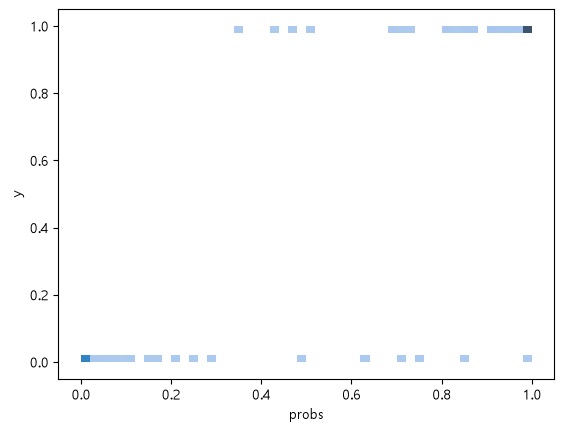

In [102]:
df = pd.DataFrame(
    torch.cat([y, probs], dim= 1).detach().numpy(),     # 정답과 예측값 열방향으로 합쳐, 텐서를 graph 추적 삭제 후 numpy 형태로 변환
    columns= ['y','probs']                              
    )

sns.histplot(
    df, x= 'probs', y= 'y', bins= 50, stat= "probability"
)

## 과제 (90% 까지 올려보기)
- 상관 관계가 있는 컬럼만 선택해서 사용해본다.
- 스케일링 작업을 해서 모델의 성능을 높인다.